## Desarrollo tarea HW Sesión 5

Felipe López Vergara

## 1. Fundamentos Teóricos: Estacionariedad, Persistencia y Momentos en GARCH(1,1)

Considere el modelo GARCH(1,1):

\begin{equation*}
\begin{aligned}
r_t &= \mu + \varepsilon_t \\
\varepsilon_t &= \sigma_t z_t,\quad z_t \overset{\text{iid}}{\sim} \mathcal{N}(0,1) \\
\sigma_t^2 &= \omega + \alpha \varepsilon_{t-1}^2 + \beta \sigma_{t-1}^2
\end{aligned}
\end{equation*}

con $\omega > 0$ y $\alpha,\beta \ge 0$.

### 1.1 Estacionariedad en Covarianza

**(a)** Muestre que, escribiendo $\sigma_t^2$ como un proceso ARMA(1,1) en $\epsilon_t^2$ (representación ARCH($\infty$)), la condición necesaria y suficiente para que el proceso sea débilmente estacionario es $\alpha+\beta<1$.


**Respuesta**

### Describir $(\varepsilon_t^2)$

Como

$\varepsilon_t = \sigma_t z_t,$

entonces

$\varepsilon_t^2 = \sigma_t^2 z_t^2.$

Definimos $u_t = \sigma_t^2\left(z_t^2 - 1\right).$

Como

$E(z_t^2)=1,$

se tiene

$E\!\left(u_t \mid \mathcal{F}_{t-1}\right)=0,$

por lo que \(u_t\) es un **ruido blanco de diferencia de martingala**.

Luego,

$\begin{aligned}\varepsilon_t^2&= \sigma_t^2 + \sigma_t^2(z_t^2-1) \\&= \sigma_t^2 + u_t.\end{aligned}$

Es decir,

$\sigma_t^2 = \varepsilon_t^2 - u_t.$

### Sustituir en la ecuación GARCH
La ecuación original del modelo GARCH(1,1) es

$\sigma_t^2 = \omega + \alpha \varepsilon_{t-1}^2 + \beta \sigma_{t-1}^2.$

Como

$\sigma_{t-1}^2 = \varepsilon_{t-1}^2 - u_{t-1},$

al sustituir se obtiene

$\begin{aligned}\sigma_t^2&= \omega + \alpha \varepsilon_{t-1}^2+ \beta\left(\varepsilon_{t-1}^2 - u_{t-1}\right) \\&= \omega + (\alpha+\beta)\varepsilon_{t-1}^2- \beta u_{t-1}.\end{aligned}$

Finalmente, como

$\varepsilon_t^2 = \sigma_t^2 + u_t,$

se concluye que

$\begin{aligned}\varepsilon_t^2&= \omega + (\alpha+\beta)\varepsilon_{t-1}^2- \beta u_{t-1} + u_t \\&= \omega + (\alpha+\beta)\varepsilon_{t-1}^2+ u_t - \beta u_{t-1}.\end{aligned}$

Esta es exactamente la representación de un modelo **ARMA(1,1)** para $(\varepsilon_t^2)$, con

- **Parte autorregresiva (AR(1))**:
  $\phi = \alpha + \beta.$

- **Parte de medias móviles (MA(1))**:
  $\theta = -\beta.$

### Condición de estacionariedad

En un proceso AR(1)

$X_t = \phi X_{t-1} + e_t,$

el cual es estacionario si y solo si

$|\phi| < 1.$

En la representación ARMA(1,1) obtenida para $(\varepsilon_t^2)$, el coeficiente autorregresivo es

$\phi = \alpha + \beta.$

Como, por definición del modelo GARCH(1,1),

$\alpha \ge 0, \qquad \beta \ge 0,$

la condición de estacionariedad se reduce a

$\alpha + \beta < 1.$

Por lo tanto, la condición necesaria y suficiente para que un proceso GARCH(1,1) sea débilmente estacionario (es decir, tenga una varianza incondicional constante y finita) es

$\boxed{\alpha + \beta < 1.}$

**(b)** Bajo dicha condición, derive la varianza incondicional:

$\sigma^2 = \mathbb{E}[\sigma_t^2]= \frac{\omega}{1-\alpha-\beta}.$

**Respuesta**

Queremos calcular la varianza incondicional del proceso,

$\sigma^2 = \mathbb{E}[\varepsilon_t^2].$

Partimos de la ecuación del modelo GARCH(1,1):

$\sigma_t^2= \omega + \alpha \varepsilon_{t-1}^2+ \beta \sigma_{t-1}^2.$

Tomando esperanza en ambos lados de la ecuación se obtiene

$\mathbb{E}[\sigma_t^2]= \omega+ \alpha \mathbb{E}[\varepsilon_{t-1}^2]+ \beta \mathbb{E}[\sigma_{t-1}^2].$

Bajo la condición de estacionariedad $\alpha+\beta<1$,

$\mathbb{E}[\sigma_t^2]=\mathbb{E}[\sigma_{t-1}^2]=\mathbb{E}[\varepsilon_t^2]=\sigma^2.$

Por lo tanto,

$\sigma^2= \omega + \alpha\sigma^2 + \beta\sigma^2.$

Agrupando los términos en \(\sigma^2\),

$\sigma^2(1-\alpha-\beta)=\omega.$

Finalmente, despejando $(\sigma^2)$,

$\boxed{\sigma^2=\frac{\omega}{1-\alpha-\beta}}.$

Esta es la **varianza incondicional** del proceso GARCH(1,1), la cual existe siempre que se cumpla la condición de estacionariedad

$\alpha+\beta<1.$

**(c)** ¿Qué ocurre con $\sigma^2$ cuando $\alpha+\beta -> 1$? Interprete este límite en términos del modelo `IGARCH` (Integrated GARCH).

**Respuesta**

En el cuadro anterior se obtuvo que la varianza incondicional del proceso GARCH(1,1) es

$\sigma^2=\frac{\omega}{1-\alpha-\beta}.$

Si

$\alpha+\beta \rightarrow 1,$

entonces

$1-\alpha-\beta \rightarrow 0^{+},$

por lo que

$\sigma^2=\frac{\omega}{1-\alpha-\beta}\longrightarrow \infty.$

Es decir, la **varianza incondicional deja de existir** (se vuelve infinita).

#### Interpretación: modelo IGARCH

Cuando

$\alpha+\beta=1,$

el modelo recibe el nombre de **Integrated GARCH (IGARCH)**.

En este caso:

-No existe una varianza incondicional finita;
-Los choques de volatilidad son permanentes;
-La volatilidad presenta persistencia infinita: un shock no desaparece con el tiempo;
-La varianza condicional depende fuertemente de toda la historia pasada y no converge a un nivel de largo plazo.

Por ello, un IGARCH describe mercados donde la volatilidad es altamente persistente y tarda indefinidamente en regresar a un valor de equilibrio.

## 1.2 Persistencia y Vida Media de un Shock

Un shock de volatilidad en $t$ decae geométricamente a tasa $(\alpha+\beta)$.

**(a)** Muestre que $\mathbb{E}\!\left[\sigma_{t+h}^2-\sigma^2 \,\middle|\, \mathcal{F}_t\right]=(\alpha+\beta)^h\left(\sigma_{t+1}^2-\sigma^2\right).$

**Respuesta**

### A partir del modelo GARCH(1,1)

La ecuación del modelo es

$\sigma_t^2=\omega+\alpha\varepsilon_{t-1}^2+\beta\sigma_{t-1}^2.$

Además,

$\mathbb{E}\!\left[\varepsilon_t^2 \mid \mathcal{F}_{t-1}\right]=\sigma_t^2.$

Por lo tanto,

$\mathbb{E}\!\left[\sigma_{t+1}^2 \mid \mathcal{F}_t\right]=\omega+\alpha\,\mathbb{E}\!\left[\varepsilon_t^2 \mid \mathcal{F}_t\right]+\beta\sigma_t^2.$

Como

$\mathbb{E}\!\left[\varepsilon_t^2 \mid \mathcal{F}_t\right]=\sigma_t^2,$

se obtiene

$\mathbb{E}\!\left[\sigma_{t+1}^2 \mid \mathcal{F}_t\right]=\omega+(\alpha+\beta)\sigma_t^2.$

#### Restar la varianza de largo plazo

La varianza incondicional es

$\sigma^2=\frac{\omega}{1-\alpha-\beta},$

lo que implica

$\omega=(1-\alpha-\beta)\sigma^2.$

Sustituyendo en la expresión anterior,

$\mathbb{E}\!\left[\sigma_{t+1}^2 \mid \mathcal{F}_t\right]=(1-\alpha-\beta)\sigma^2+(\alpha+\beta)\sigma_t^2.$

Restando $(\sigma^2)$ en ambos lados,

$\begin{aligned}\mathbb{E}\!\left[\sigma_{t+1}^2-\sigma^2\,\middle|\,\mathcal{F}_t\right]&=(\alpha+\beta)(\sigma_t^2-\sigma^2).\end{aligned}$

#### Aplicar recursión

Un paso más adelante,

$\mathbb{E}\!\left[\sigma_{t+2}^2-\sigma^2\,\middle|\,\mathcal{F}_t\right]=(\alpha+\beta)\mathbb{E}\!\left[\sigma_{t+1}^2-\sigma^2\,\middle|\,\mathcal{F}_t\right].$

Sustituyendo el resultado anterior,

$\mathbb{E}\!\left[\sigma_{t+2}^2-\sigma^2\,\middle|\,\mathcal{F}_t\right]=(\alpha+\beta)^2(\sigma_t^2-\sigma^2).$

Repitiendo el argumento por inducción para un horizonte $(h)$,

$\boxed{\mathbb{E}\!\left[\sigma_{t+h}^2-\sigma^2\,\middle|\,\mathcal{F}_t\right]=(\alpha+\beta)^h(\sigma_t^2-\sigma^2).}$

Esta expresión demuestra que un **shock de volatilidad** se desvanece geométricamente a una tasa igual a $(\alpha+\beta)$. En consecuencia, cuanto más cercano sea $(\alpha+\beta)$ a 1, mayor será la persistencia de la volatilidad y más lentamente desaparecerá el efecto del shock.

**(b)** Defina la **vida media** (*half-life*) de un shock como el número de períodos $(h^{*})$ necesario para que la desviación de la varianza condicional respecto de su nivel de largo plazo, $(\sigma^2)$, se reduzca a la mitad. Muestre que

$h^{*}=\frac{\ln(0.5)}{\ln(\alpha+\beta)}.$

**Respuesta**

La **vida media** (*half-life*) de un shock se define como el número de períodos necesarios para que el efecto de dicho shock sobre la varianza condicional se reduzca a la mitad.

Del ejercicio anterior,

$(\alpha+\beta)^h(\sigma_t^2-\sigma^2)$

representa el efecto remanente del shock después de $(h)$ períodos.

Por definición de vida media,

$(\alpha+\beta)^{h^{*}}=\frac{1}{2}.$

Tomando logaritmos naturales en ambos lados,

$h^{*}\ln(\alpha+\beta)=\ln(0.5).$

Despejando \(h^{*}\),

$\boxed{h^{*}=\frac{\ln(0.5)}{\ln(\alpha+\beta)}}.$

Como

$0<\alpha+\beta<1,$

se tiene que

$\ln(\alpha+\beta)<0\quad\text{y}\quad\ln(0.5)<0,$

por lo que

$h^{*}>0.$

En consecuencia, cuanto más cercano sea $(\alpha+\beta)$ a 1, mayor será la vida media del shock y más lentamente desaparecerá el efecto de una perturbación sobre la volatilidad.

**(c)** Calcula $h^{*}$ para $(\alpha,\beta) = (0,05, 0,90)$, $(0,10, 0,85)$ y $(0,02, 0,97)$. ¿Qué combinación implica volatilidad más persistente?

La vida media de un shock está dada por

$h^{*}=\frac{\ln(0.5)}{\ln(\alpha+\beta)}.$

El valor del ln de 0,5 es $[\ln(0.5)=-0.693147.$

#### Primer caso: $((\alpha,\beta)=(0.05,\,0.90))$

En este caso,

$\alpha+\beta=0.95.$

Por lo tanto,

$\begin{aligned}h^{*}&=\frac{\ln(0.5)}{\ln(0.95)} \\&=\frac{-0.693147}{-0.051293} \\&\approx 13.52.\end{aligned}$

Así,

$\boxed{h^{*}\approx 13.5 \text{ períodos}.}$

#### Segundo caso: $((\alpha,\beta)=(0.10,\,0.85))$

Nuevamente,

$\alpha+\beta=0.95,$

por lo que

$\boxed{h^{*}\approx 13.5 \text{ períodos}.}$

Aunque los parámetros individuales cambian, la persistencia depende únicamente de la suma $\alpha+\beta$.

#### Tercer caso: $(\alpha,\beta)=(0.02,\,0.97)$

En este caso,

$\alpha+\beta=0.99.$

Entonces,

$\begin{aligned}h^{*}&=\frac{\ln(0.5)}{\ln(0.99)} \\&=\frac{-0.693147}{-0.010050} \\&\approx 68.97.\end{aligned}$

Por lo tanto,

$\boxed{h^{*}\approx 69 \text{ períodos}.}$

### Interpretación

| $(\alpha,\beta)$ | $(\alpha+\beta)$ | Vida media |
|:------------------:|:----------------:|:----------:|
| \((0.05,\;0.90)\) | 0.95 | 13.5 períodos |
| \((0.10,\;0.85)\) | 0.95 | 13.5 períodos |
| \((0.02,\;0.97)\) | 0.99 | 69 períodos |

Se observa que:

- Los dos primeros modelos presentan exactamente la misma persistencia, ya que comparten el mismo valor de \(\alpha+\beta=0.95\). En consecuencia, ambos tienen una vida media de aproximadamente **13.5 períodos**.
- El tercer modelo presenta una persistencia considerablemente mayor. Al tener \(\alpha+\beta=0.99\), los efectos de un shock sobre la volatilidad se disipan muy lentamente, requiriendo aproximadamente **69 períodos** para reducirse a la mitad.
- Este comportamiento es característico de modelos cercanos a un **IGARCH**, donde la volatilidad exhibe una elevada persistencia y los choques tienen efectos de muy larga duración.

### 1.3 Momento de Cuarto Orden y Curtosis

Asumiendo $z_t\sim\mathcal{N}(0,1)$ y $3\alpha^2+2\alpha\beta+\beta^2<1$ (condición para que exista el cuarto momento incondicional):

**(a)** Muestre que la curtosis incondicional de $\epsilon_t$ es:
$$\kappa=\frac{3\left[1-(\alpha+\beta)^2\right]}{1-(\alpha+\beta)^2-2\alpha^2}.$$

**Respuesta**

#### Definición de curtosis

La curtosis incondicional es

$\kappa=\frac{E[\varepsilon_t^4]}{\left(E[\varepsilon_t^2]\right)^2}.$

Como

$\varepsilon_t=\sigma_t z_t,$

y $z_t \sim N(0,1)$,

$E[z_t^4]=3.$

Por independencia entre \(z_t\) y \(\sigma_t\),

$E[\varepsilon_t^4]= E[\sigma_t^4]E[z_t^4]= 3E[\sigma_t^4].$

Por tanto,

$\boxed{\kappa=3\frac{E[\sigma_t^4]}{\sigma^4}}$

donde

$\sigma^2=E[\sigma_t^2]=\frac{\omega}{1-\alpha-\beta}.$

#### Elevar al cuadrado la ecuación GARCH

El modelo es

$\sigma_t^2=\omega+\alpha\varepsilon_{t-1}^2+\beta\sigma_{t-1}^2.$

Elevando al cuadrado,

$\sigma_t^4=\left(\omega+\alpha\varepsilon_{t-1}^2+\beta\sigma_{t-1}^2\right)^2.$

Expandiendo,

$\begin{aligned}\sigma_t^4=&\ \omega^2+\alpha^2\varepsilon_{t-1}^4+\beta^2\sigma_{t-1}^4 \\&+2\omega\alpha\varepsilon_{t-1}^2+2\omega\beta\sigma_{t-1}^2+2\alpha\beta\varepsilon_{t-1}^2\sigma_{t-1}^2.\end{aligned}$

#### Tomar esperanza

Sea

$M_4=E[\sigma_t^4].$

Además,

$E[\varepsilon_t^2]=\sigma^2,\qquad E[\varepsilon_t^4]=3M_4,$
y

$E[\varepsilon_t^2\sigma_t^2]=E[\sigma_t^4 z_t^2]=M_4.$

Sustituyendo,

$\begin{aligned}M_4=&\ \omega^2+3\alpha^2 M_4+\beta^2 M_4 \\&+2\omega(\alpha+\beta)\sigma^2+2\alpha\beta M_4.\end{aligned}$

Agrupando,

$M_4\left[1-3\alpha^2-2\alpha\beta-\beta^2\right]=\omega^2+2\omega(\alpha+\beta)\sigma^2.$

#### Simplificar

Como

$\omega=(1-\alpha-\beta)\sigma^2,$

se obtiene

$\omega^2+2\omega(\alpha+\beta)\sigma^2=(1-\alpha-\beta)(1+\alpha+\beta)\sigma^4.$

Pero

$(1-\alpha-\beta)(1+\alpha+\beta)=1-(\alpha+\beta)^2.$

Entonces

$M_4=\frac{1-(\alpha+\beta)^2}{1-3\alpha^2-2\alpha\beta-\beta^2}\sigma^4.$

Como

$3\alpha^2+2\alpha\beta+\beta^2=(\alpha+\beta)^2+2\alpha^2,$

el denominador queda

$1-(\alpha+\beta)^2-2\alpha^2.$

Finalmente,

$\boxed{\kappa=\frac{3\left[1-(\alpha+\beta)^2\right]}{1-(\alpha+\beta)^2-2\alpha^2}.}$


**(b)** Muestre que $\kappa > 3$ siempre que $\alpha>0$, es decir, que el modelo GARCH(1,1) con innovaciones normales genera **exceso de curtosis** incondicional (leptocurtosis) aunque $z_t$ sea gaussiano. Relacione este resultado con los hechos estilizados vistos en clases.

**Respuesta**

Escribimos

$\kappa=3\frac{A}{A-2\alpha^2}$

donde

$A=1-(\alpha+\beta)^2.$

Como existe el cuarto momento,

$A-2\alpha^2>0.$

Además,

$A > A-2\alpha^2,$

por lo que

$\frac{A}{A-2\alpha^2}>1.$

Multiplicando por 3,

$\boxed{\kappa>3.}$

#### Interpretación

La distribución normal tiene

$\kappa=3.$

En cambio, el modelo GARCH produce

$\kappa>3,$

incluso cuando $(z_t \sim N(0,1))$. Esto ocurre porque la volatilidad es estocástica, generando colas más pesadas (leptocurtosis).

**(c)** Verifique la condición de existencia del cuarto momento para los tres pares $(\alpha,\beta)$ del punto 1.2(c). ¿Existe algún caso en que la curtosis no esté definida?

**Respuesta**

La condición es

$\boxed{3\alpha^2+2\alpha\beta+\beta^2<1.}$

#### Caso 1

$[(\alpha,\beta)=(0.05,0.90)]$

$3(0.05)^2 + 2(0.05)(0.90) + (0.90)^2= 0.9075 < 1.$

**Existe el cuarto momento.**

#### Caso 2

$(\alpha,\beta)=(0.10,0.85)$

$0.03 + 0.17 + 0.7225 = 0.9225 < 1.$

**Existe el cuarto momento.**

#### Caso 3

$(\alpha,\beta)=(0.02,0.97)$

$0.0012 + 0.0388 + 0.9409 = 0.9809 < 1.$

**También existe el cuarto momento.**


### Conclusión

| $(\alpha,\beta)$ | $(3\alpha^2+2\alpha\beta+\beta^2)$ | ¿Existe $(E[\varepsilon_t^4])$? |
|--------------------|------------------------------------:|:------------------------------:|
| (0.05, 0.90)       | 0.9075                             | Sí |
| (0.10, 0.85)       | 0.9225                             | Sí |
| (0.02, 0.97)       | 0.9809                             | Sí |

Los tres modelos cumplen la condición $[3\alpha^2+2\alpha\beta+\beta^2<1]$ Por lo que el cuarto momento está bien definido. Sin embargo, el tercer caso está muy cercano al límite, lo que implica alta persistencia de volatilidad y colas pesadas.

## 2. Simulación de Modelos de Volatilidad

Simule 3.000 observaciones ($r_t$) con $\mu=0$ para cada uno de los siguientes procesos, descartando las primeras 500 observaciones como *burn-in*:

In [3]:
import numpy as np
import matplotlib.pyplot as plt

In [4]:
# Modelo ARCH(1)

def simulate_arch(T, omega, alpha, mu=0, burn=500, seed=123):

    np.random.seed(seed)

    n = T + burn

    z = np.random.randn(n)

    sigma2 = np.zeros(n)
    sigma = np.zeros(n)
    eps = np.zeros(n)
    r = np.zeros(n)

    # Varianza inicial
    sigma2[0] = omega/(1-alpha)

    sigma[0] = np.sqrt(sigma2[0])

    eps[0] = sigma[0]*z[0]

    r[0] = mu + eps[0]

    for t in range(1,n):

        sigma2[t] = omega + alpha*eps[t-1]**2

        sigma[t] = np.sqrt(sigma2[t])

        eps[t] = sigma[t]*z[t]

        r[t] = mu + eps[t]

    return r[burn:], sigma[burn:]

In [5]:
#Modelo ARCH (1)
r_arch, sigma_arch = simulate_arch(
    T=3000,
    omega=0.05,
    alpha=0.85
)
print(r_arch)

[ 0.16971387  0.01900598 -0.05953741 ...  0.28259539  0.29730076
 -0.06058222]


In [6]:
# Modelo GARCH (1,1)
def simulate_garch(T, omega, alpha, beta,
                   mu=0, burn=500, seed=123):

    np.random.seed(seed)

    n = T + burn

    z = np.random.randn(n)

    sigma2 = np.zeros(n)
    sigma = np.zeros(n)
    eps = np.zeros(n)
    r = np.zeros(n)

    sigma2[0] = omega/(1-alpha-beta)

    sigma[0] = np.sqrt(sigma2[0])

    eps[0] = sigma[0]*z[0]

    r[0] = mu + eps[0]

    for t in range(1,n):

        sigma2[t] = (omega
                     + alpha*eps[t-1]**2
                     + beta*sigma2[t-1])

        sigma[t] = np.sqrt(sigma2[t])

        eps[t] = sigma[t]*z[t]

        r[t] = mu + eps[t]

    return r[burn:], sigma[burn:]

# GARCH baja persistencia
r_garch1, sigma_garch1 = simulate_garch(
    T=3000,
    omega=0.05,
    alpha=0.05,
    beta=0.60
)

# GARCH alta persistencia
r_garch2, sigma_garch2 = simulate_garch(
    T=3000,
    omega=0.02,
    alpha=0.08,
    beta=0.90
)


In [7]:
# Modelo EGARCH (1,1)
def simulate_egarch(T,
                    omega,
                    alpha,
                    gamma,
                    beta,
                    mu=0,
                    burn=500,
                    seed=123):

    np.random.seed(seed)

    n = T + burn

    z = np.random.randn(n)

    log_sigma2 = np.zeros(n)
    sigma2 = np.zeros(n)
    sigma = np.zeros(n)
    eps = np.zeros(n)
    r = np.zeros(n)

    c = np.sqrt(2/np.pi)

    log_sigma2[0] = omega/(1-beta)

    sigma2[0] = np.exp(log_sigma2[0])

    sigma[0] = np.sqrt(sigma2[0])

    eps[0] = sigma[0]*z[0]

    r[0] = mu + eps[0]

    for t in range(1,n):

        log_sigma2[t] = (omega
                         + beta*log_sigma2[t-1]
                         + alpha*(abs(z[t-1])-c)
                         + gamma*z[t-1])

        sigma2[t] = np.exp(log_sigma2[t])

        sigma[t] = np.sqrt(sigma2[t])

        eps[t] = sigma[t]*z[t]

        r[t] = mu + eps[t]

    return r[burn:], sigma[burn:]

# Modelo EGARCH
r_egarch, sigma_egarch = simulate_egarch(
    T=3000,
    omega=0.01,
    alpha=0.10,
    gamma=-0.08,
    beta=0.95
)

In [8]:
# Modelo GJR-GARCH (1,1)
def simulate_gjr(T,
                 omega,
                 alpha,
                 gamma,
                 beta,
                 mu=0,
                 burn=500,
                 seed=123):

    np.random.seed(seed)

    n = T + burn

    z = np.random.randn(n)

    sigma2 = np.zeros(n)
    sigma = np.zeros(n)
    eps = np.zeros(n)
    r = np.zeros(n)

    sigma2[0] = omega/(1-alpha-beta-gamma/2)

    sigma[0] = np.sqrt(sigma2[0])

    eps[0] = sigma[0]*z[0]

    r[0] = mu + eps[0]

    for t in range(1,n):

        indicador = 1 if eps[t-1] < 0 else 0

        sigma2[t] = (omega
                     + alpha*eps[t-1]**2
                     + gamma*indicador*eps[t-1]**2
                     + beta*sigma2[t-1])

        sigma[t] = np.sqrt(sigma2[t])

        eps[t] = sigma[t]*z[t]

        r[t] = mu + eps[t]

    return r[burn:], sigma[burn:]

# Modelo GJR-GARCH
r_gjr, sigma_gjr = simulate_gjr(
    T=3000,
    omega=0.02,
    alpha=0.03,
    gamma=0.09,
    beta=0.90
)


**(b)** Grafique en un mismo panel la serie simulada $r_t$ y su volatilidad condicional $\sigma_t$

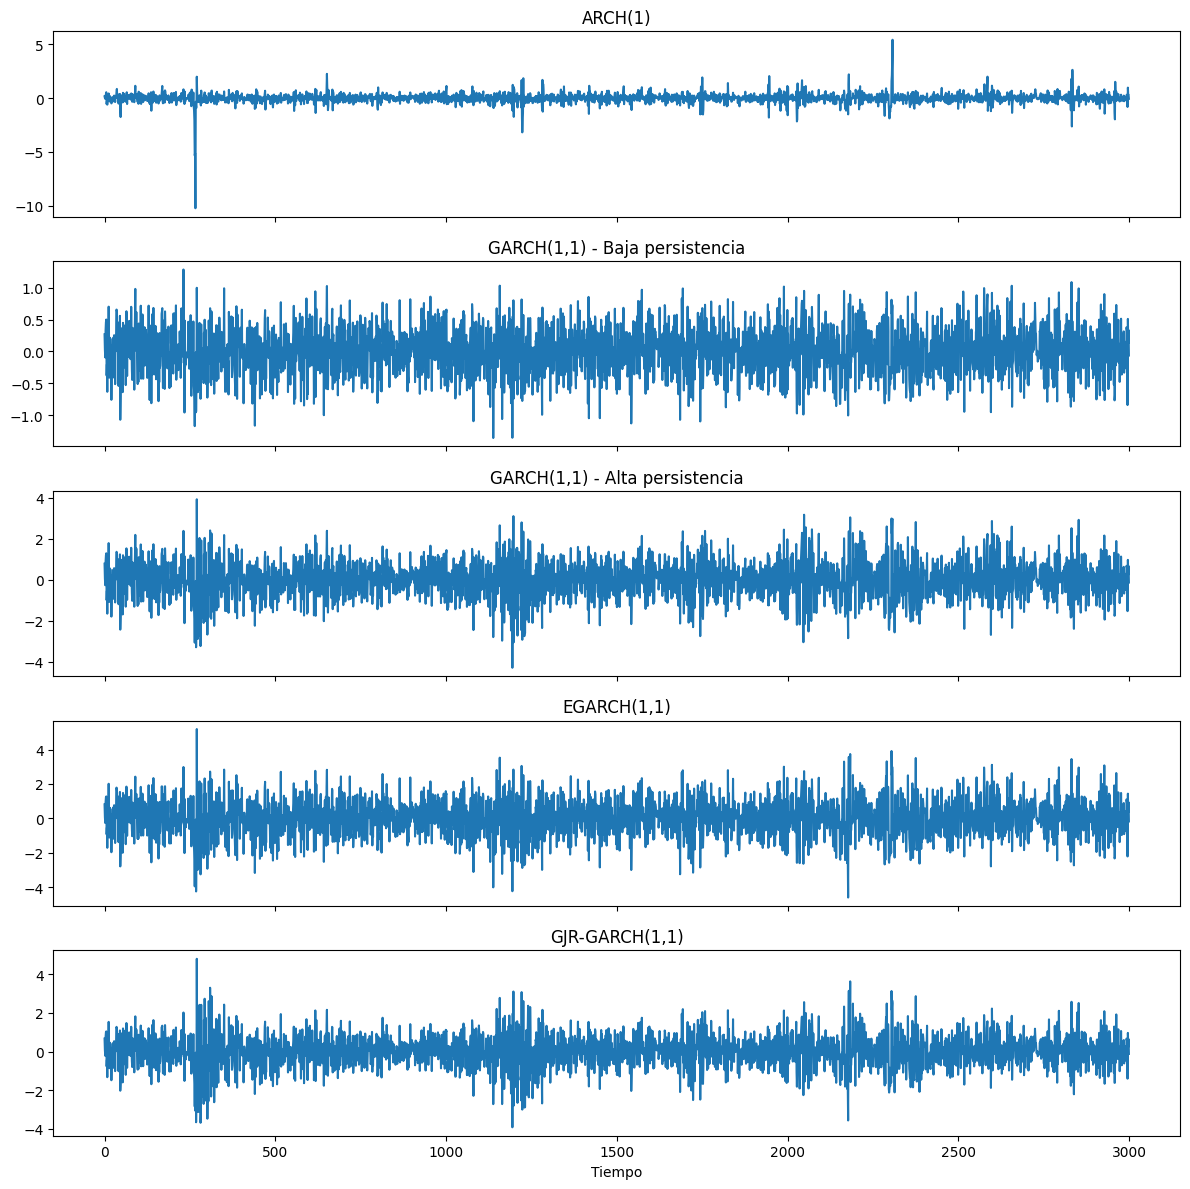

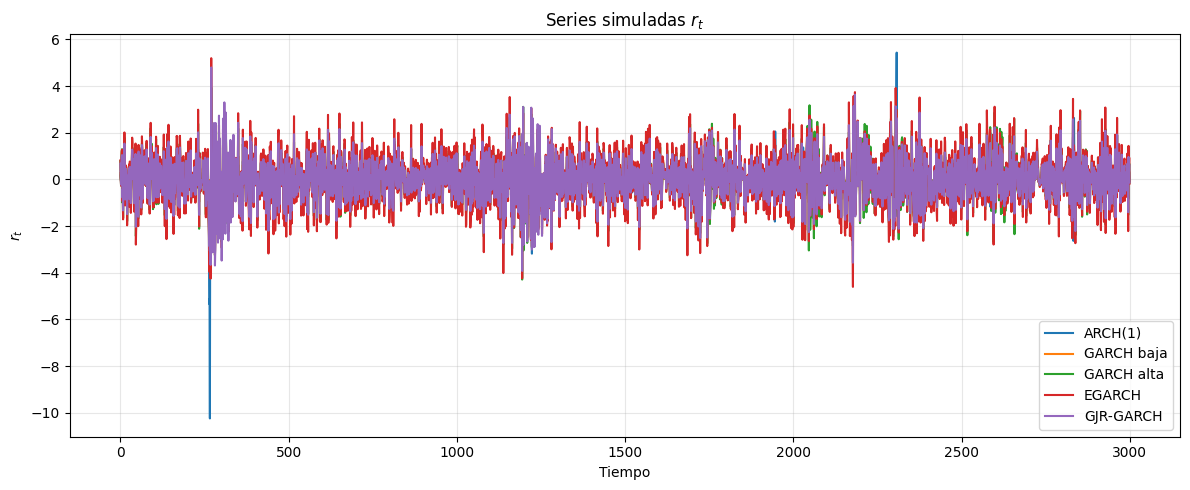

In [9]:
#Gráficos de las series simuladas

fig, ax = plt.subplots(5, 1, figsize=(12,12), sharex=True)

ax[0].plot(r_arch)
ax[0].set_title("ARCH(1)")

ax[1].plot(r_garch1)
ax[1].set_title("GARCH(1,1) - Baja persistencia")

ax[2].plot(r_garch2)
ax[2].set_title("GARCH(1,1) - Alta persistencia")

ax[3].plot(r_egarch)
ax[3].set_title("EGARCH(1,1)")

ax[4].plot(r_gjr)
ax[4].set_title("GJR-GARCH(1,1)")
ax[4].set_xlabel("Tiempo")

plt.tight_layout()
plt.show()

#Gráficos de las series simuladas todas juntas

plt.figure(figsize=(12,5))

plt.plot(r_arch, label="ARCH(1)")
plt.plot(r_garch1, label="GARCH baja")
plt.plot(r_garch2, label="GARCH alta")
plt.plot(r_egarch, label="EGARCH")
plt.plot(r_gjr, label="GJR-GARCH")

plt.title("Series simuladas $r_t$")
plt.xlabel("Tiempo")
plt.ylabel("$r_t$")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

**(c)** Para los dos GARCH(1,1) simulados, calcule la varianza muestral de $\epsilon_t^2$ sobre las 2.500 observaciones post *burn-in* y compárela con la varianza incondicional teórica $\omega/(1-\alpha-\beta)$ derivada en 1.1(b). Comente la calidad de la aproximación y cómo cambia si aumenta el número de simulaciones a 50.000.


$\begin{aligned}
r_t &= \varepsilon_t, \\
\varepsilon_t &= \sigma_t z_t, \\
\sigma_t^2 &= \omega + \alpha \varepsilon_{t-1}^2 + \beta \sigma_{t-1}^2,\end{aligned}$

la varianza incondicional está dada por

$operatorname{Var}(\varepsilon_t)=\frac{\omega}{1-\alpha-\beta},$

siempre que se cumpla la condición de estacionariedad

$\alpha + \beta < 1.$


In [10]:
# Simulación GARCH(1,1) baja persistencia
r1, sigma1 = simulate_garch(
    T=3000,
    omega=0.05,
    alpha=0.05,
    beta=0.60
)

# Varianza muestral
var_muestral1 = np.var(r1, ddof=1)

# Varianza teórica
var_teorica1 = 0.05/(1-0.05-0.60)

print(f"Varianza muestral : {var_muestral1:.4f}")
print(f"Varianza teórica  : {var_teorica1:.4f}")

Varianza muestral : 0.1351
Varianza teórica  : 0.1429


In [11]:
# Simulación GARCH(1,1) alta persistencia

r2, sigma2 = simulate_garch(
    T=3000,
    omega=0.02,
    alpha=0.08,
    beta=0.90
)

var_muestral2 = np.var(r2, ddof=1)

var_teorica2 = 0.02/(1-0.08-0.90)

print(f"Varianza muestral : {var_muestral2:.4f}")
print(f"Varianza teórica  : {var_teorica2:.4f}")

Varianza muestral : 0.8176
Varianza teórica  : 1.0000


In [12]:
# Simulación GARCH(1,1) baja persistencia 50.000 Observaciones
r1, sigma1 = simulate_garch(
    T=50000,
    omega=0.05,
    alpha=0.05,
    beta=0.60
)

# Varianza muestral
var_muestral1 = np.var(r1, ddof=1)

# Varianza teórica
var_teorica1 = 0.05/(1-0.05-0.60)

print(f"Varianza muestral : {var_muestral1:.4f}")
print(f"Varianza teórica  : {var_teorica1:.4f}")

Varianza muestral : 0.1430
Varianza teórica  : 0.1429


In [13]:
# Simulación GARCH(1,1) alta persistencia 50.000 Observaciones

r2, sigma2 = simulate_garch(
    T=50000,
    omega=0.02,
    alpha=0.08,
    beta=0.90
)

var_muestral2 = np.var(r2, ddof=1)

var_teorica2 = 0.02/(1-0.08-0.90)

print(f"Varianza muestral : {var_muestral2:.4f}")
print(f"Varianza teórica  : {var_teorica2:.4f}")

Varianza muestral : 0.9873
Varianza teórica  : 1.0000


Al aumentar el número de observaciones simuladas a 50.000, la varianza muestral converge hacia la varianza incondicional teórica en ambos modelos, de acuerdo con la Ley de los Grandes Números. La diferencia entre ambas medidas disminuye considerablemente y la aproximación es especialmente notoria en el modelo de alta persistencia, donde se requiere un tamaño muestral mayor para reproducir adecuadamente el comportamiento de largo plazo del proceso.

**(d)** Compare visualmente la asimetría del EGARCH y del GJR-GARCH: simule choques $z_t$ idénticos (misma semilla) para ambos modelos y grafique $\sigma_t$ resultante ante una racha de choques negativos vs. una racha de choques positivos de igual magnitud. ¿Qué modelo reacciona más fuerte a los choques negativos?

In [14]:
# Modelo EGARCH (1,1)

def simulate_egarch_given_z(z, omega, alpha, gamma, beta):

    n = len(z)

    log_sigma2 = np.zeros(n)
    sigma2 = np.zeros(n)

    c = np.sqrt(2/np.pi)

    log_sigma2[0] = omega/(1-beta)
    sigma2[0] = np.exp(log_sigma2[0])

    for t in range(1,n):

        log_sigma2[t] = (omega
                         + beta*log_sigma2[t-1]
                         + alpha*(abs(z[t-1])-c)
                         + gamma*z[t-1])

        sigma2[t] = np.exp(log_sigma2[t])

    return np.sqrt(sigma2)

In [15]:
# Modelo GJR-GARCH (1,1)

def simulate_gjr_given_z(z, omega, alpha, gamma, beta):

    n = len(z)

    sigma2 = np.zeros(n)
    eps = np.zeros(n)

    sigma2[0] = omega/(1-alpha-beta-gamma/2)

    eps[0] = np.sqrt(sigma2[0])*z[0]

    for t in range(1,n):

        indicador = 1 if eps[t-1] < 0 else 0

        sigma2[t] = (omega
                     + alpha*eps[t-1]**2
                     + gamma*indicador*eps[t-1]**2
                     + beta*sigma2[t-1])

        eps[t] = np.sqrt(sigma2[t])*z[t]

    return np.sqrt(sigma2)

In [16]:
# Choques positivos y negativos

#Positivo
T = 200
z_pos = np.ones(T)

#Negativo
z_neg = -np.ones(T)

In [17]:
# Modelo EGARCH (1,1) choques positivos y negativos

sigma_pos_eg = simulate_egarch_given_z(
    z_pos,
    omega=0.01,
    alpha=0.10,
    gamma=-0.08,
    beta=0.95
)

sigma_neg_eg = simulate_egarch_given_z(
    z_neg,
    omega=0.01,
    alpha=0.10,
    gamma=-0.08,
    beta=0.95
)

# Modelo GJR-GARCH (1,1) choques positivos y negativos

sigma_pos_gjr = simulate_gjr_given_z(
    z_pos,
    omega=0.02,
    alpha=0.03,
    gamma=0.09,
    beta=0.90
)

sigma_neg_gjr = simulate_gjr_given_z(
    z_neg,
    omega=0.02,
    alpha=0.03,
    gamma=0.09,
    beta=0.90
)

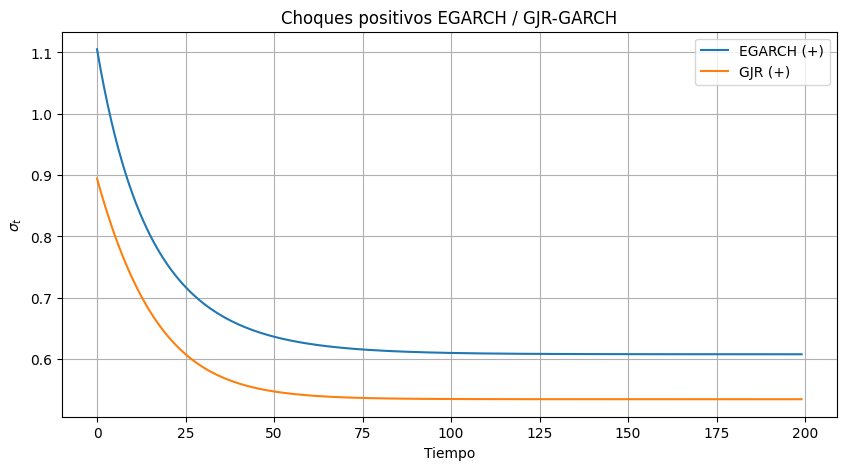

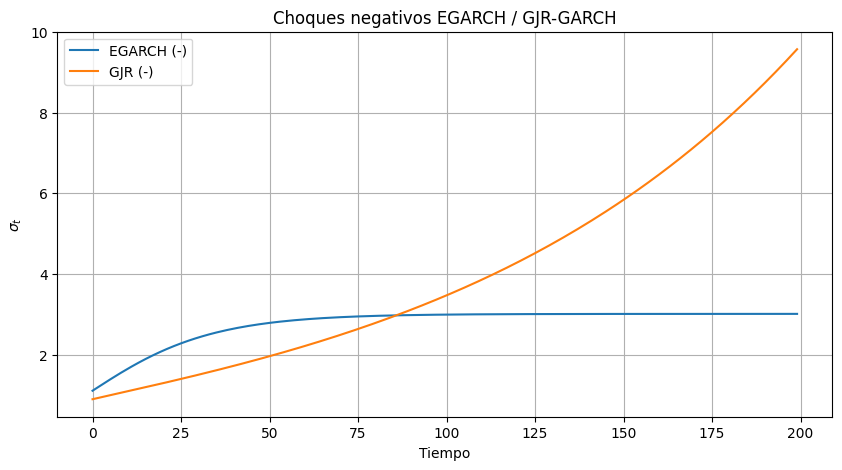

In [18]:
#Gráficos de las series simuladas para choques positivos y negativos
plt.figure(figsize=(10,5))

plt.plot(sigma_pos_eg, label="EGARCH (+)")
plt.plot(sigma_pos_gjr, label="GJR (+)")

plt.title("Choques positivos EGARCH / GJR-GARCH")
plt.ylabel(r"$\sigma_t$")
plt.xlabel("Tiempo")
plt.legend()
plt.grid(True)

plt.figure(figsize=(10,5))

plt.plot(sigma_neg_eg, label="EGARCH (-)")
plt.plot(sigma_neg_gjr, label="GJR (-)")

plt.title("Choques negativos EGARCH / GJR-GARCH")
plt.ylabel(r"$\sigma_t$")
plt.xlabel("Tiempo")
plt.legend()
plt.grid(True)

plt.show()

Se utilizaron choques estandarizados idénticos para ambos modelos, considerando una secuencia de choques positivos $z_t = 1$ y otra de igual magnitud pero negativos $z_t = -1$. Esto permite aislar el efecto de la asimetría incorporada en cada especificación.

En el modelo **EGARCH**, la asimetría proviene del término $\gamma z_{t-1}$. Dado que $\gamma = -0.08$, los choques negativos generan un incremento mayor en la volatilidad condicional que los choques positivos de igual magnitud. La respuesta es continua, ya que depende directamente del signo y del tamaño del choque.

En el modelo **GJR-GARCH**, la asimetría se introduce mediante el término $\gamma I(\varepsilon_{t-1}<0)\varepsilon_{t-1}^{2}$. Cuando el choque es negativo, el indicador toma valor uno y se añade un componente adicional a la varianza condicional; para choques positivos, dicho término es cero. Esto produce un aumento más pronunciado de la volatilidad frente a choques negativos.

En las simulaciones se observa que ambos modelos reproducen el **efecto de apalancamiento** (*leverage effect*), pero el **GJR-GARCH** presenta una reacción más intensa frente a una racha de choques negativos, mientras que el **EGARCH** genera una respuesta asimétrica más gradual. Por lo tanto, para los parámetros utilizados, el **GJR-GARCH** reacciona más fuertemente a los choques negativos.


## 3. Estimación por Máxima Verosimilitud de un GARCH(1,1) Programada desde Cero

Use la serie **GARCH(1,1) de alta persistencia** simulada en el Ejercicio 2 ($\omega=0,02$, $\alpha=0,08$, $\beta=0,90$).

### 3.1 Log-Verosimilitud Condicional

Bajo $z_t\sim\mathcal{N}(0,1)$, la contribución de cada observación a la log-verosimilitud es $$\ell_t(\boldsymbol{\psi}) =-\frac{1}{2}\left[\ln(2\pi)+\ln(\sigma_t^2)+\frac{\varepsilon_t^2}{\sigma_t^2}\right]$$

con $\boldsymbol{\psi}=(\omega,\alpha,\beta)^\top$ y $\sigma_1^2$ se inicializa con la varianza muestral de $\varepsilon_t$.

In [19]:
import numpy as np

def compute_conditional_variance(psi, eps):
    """
    Calcula recursivamente la varianza condicional de un GARCH(1,1).

    Parámetros
    ----------
    psi : iterable
        (omega, alpha, beta)
    eps : array-like
        Residuos epsilon_t

    Retorna
    -------
    sigma2 : ndarray
        Varianzas condicionales sigma_t^2
    """

    omega, alpha, beta = psi
    eps = np.asarray(eps)

    T = len(eps)
    sigma2 = np.zeros(T)

    # Condición inicial
    sigma2[0] = np.var(eps, ddof=1)

    # Recursión GARCH(1,1)
    for t in range(1, T):
        sigma2[t] = (
            omega
            + alpha * eps[t-1]**2
            + beta * sigma2[t-1]
        )

    return sigma2

In [20]:
# Residuos GARCH alta persistencia
eps = r_garch2 - np.mean(r_garch2)

# Parámetros verdaderos
psi = (0.02, 0.08, 0.90)

# Varianzas condicionales
sigma2 = compute_conditional_variance(psi, eps)

# Desviación estándar condicional
sigma = np.sqrt(sigma2)

print(sigma2[:10])

[0.8175863  0.80521461 0.74507247 0.69617235 0.70850031 0.77080325
 0.84740768 0.86146263 0.81834352 0.97502074]


**(b)** Implemente neg_log_likelihood(psi, eps) que regrese $-\sum_{t=1}^{T}\ell_t(\boldsymbol{\psi})$

In [21]:
def neg_log_likelihood(psi, eps):
    """
    Calcula la log-verosimilitud condicional negativa
    de un modelo GARCH(1,1).

    Parámetros
    ----------
    psi : iterable
        (omega, alpha, beta)
    eps : array-like
        Residuos epsilon_t

    Retorna
    -------
    float
        -sum_t l_t(psi)
    """
    eps = np.asarray(eps)

    # Varianzas condicionales
    sigma2 = compute_conditional_variance(psi, eps)

    # Evita problemas numéricos
    if np.any(sigma2 <= 0):
        return np.inf

    # Log-verosimilitud
    loglik = -0.5 * np.sum(
        np.log(2 * np.pi)
        + np.log(sigma2)
        + eps**2 / sigma2
    )

    # Se devuelve la negativa porque los optimizadores minimizan
    return -loglik

    # Parámetros verdaderos
psi = (0.02, 0.08, 0.90)

# Residuos de la serie simulada
eps = r_garch2 - np.mean(r_garch2)

# Valor de la función objetivo
nll = neg_log_likelihood(psi, eps)

print(f"Función de log-verosimilitud negativa: {nll:.4f}")

Función de log-verosimilitud negativa: 3779.0366


**(c)** Reparametrice para imponer $\omega>0$, $\alpha,\beta\geq 0$ y $\alpha+\beta<1$ (por ejemplo, optimizando sobre $\ln\omega$ y utilizando una transformación logística para $\alpha$ y $\beta$), o use `scipy.optimize.minimize` con `method='SLSQP'` y restricciones explícitas.

In [22]:
from scipy.optimize import minimize

psi0 = [0.05, 0.10, 0.80]

constraints = [
    {"type": "ineq", "fun": lambda x: x[0]},              # omega > 0
    {"type": "ineq", "fun": lambda x: x[1]},              # alpha >= 0
    {"type": "ineq", "fun": lambda x: x[2]},              # beta >= 0
    {"type": "ineq", "fun": lambda x: 1 - x[1] - x[2]}    # alpha + beta < 1
]

resultado = minimize(
    neg_log_likelihood,
    psi0,
    args=(eps,),
    method="SLSQP",
    constraints=constraints
)

print(resultado.x)

[0.0208904  0.079303   0.89455025]


**(d)** Minimice la función objetivo partiendo de $\boldsymbol{\psi}_0=(0.01,\,0.05,\,0.85)^\top$. Reporte el estimador $\hat{\boldsymbol{\psi}}$.

In [23]:
# Punto inicial
psi0 = np.array([0.01, 0.05, 0.85])

# Restricciones
constraints = [
    {"type": "ineq", "fun": lambda x: x[0]},              # omega > 0
    {"type": "ineq", "fun": lambda x: x[1]},              # alpha >= 0
    {"type": "ineq", "fun": lambda x: x[2]},              # beta >= 0
    {"type": "ineq", "fun": lambda x: 1 - x[1] - x[2]}    # alpha + beta < 1
]

# Optimización
resultado = minimize(
    neg_log_likelihood,
    psi0,
    args=(eps,),
    method="SLSQP",
    constraints=constraints
)

# Estimador MLE
psi_hat = resultado.x

print("Convergencia:", resultado.success)
print("Mensaje:", resultado.message)

print(f"ω̂ = {psi_hat[0]:.6f}")
print(f"α̂ = {psi_hat[1]:.6f}")
print(f"β̂ = {psi_hat[2]:.6f}")
print(f"Log-verosimilitud = {-resultado.fun:.6f}")

Convergencia: True
Mensaje: Optimization terminated successfully
ω̂ = 0.020890
α̂ = 0.079299
β̂ = 0.894554
Log-verosimilitud = -3777.221584


## 3.2 Validación con arch

Estime el mismo modelo con arch_model(eps, vol='GARCH', p=1, q=1, dist='normal') y complete la tabla:

    | Parámetro | Verdadero | MLE propio | `arch` |,
    |-----------|-----------|------------|--------|,
    | $\\omega$ | 0.02 | | |,
    | $\\alfa$ | 0.08 | | |,
    | $\\beta$ | 0.90 | | |,
    | Log-Lik. | — | | |,

Explique cualquier diferencia observada (inicialización de $\sigma_1^2$, algoritmo de optimización, escala de los datos, etc.).

In [24]:
#Modelo GARCH (1,1) Ccom arch_model
from arch import arch_model

model_garch = arch_model(eps, vol='Garch', p=1, q=1)
results_garch = model_garch.fit(disp='off')
print(results_garch.summary())

                     Constant Mean - GARCH Model Results                      
Dep. Variable:                      y   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -3776.85
Distribution:                  Normal   AIC:                           7561.70
Method:            Maximum Likelihood   BIC:                           7585.72
                                        No. Observations:                 3000
Date:                Thu, Jul 09 2026   Df Residuals:                     2999
Time:                        00:11:42   Df Model:                            1
                                  Mean Model                                 
                 coef    std err          t      P>|t|       95.0% Conf. Int.
-----------------------------------------------------------------------------
mu             0.0127  1.441e-02      0.884      0.377 

In [25]:
# Tabla comparación de parámetros
import pandas as pd

tabla = pd.DataFrame({
    "Parámetro": ["ω", "α", "β", "Log-Lik"],
    "Verdadero": ["0.02", "0.08", "0.90","-"],
    "MLE propio": [
        psi_hat[0],
        psi_hat[1],
        psi_hat[2]  ,
        -resultado.fun
    ],
        "ARCH": [
        results_garch.params["omega"],
        results_garch.params["alpha[1]"],
        results_garch.params["beta[1]"],
        results_garch.loglikelihood
    ]
})

print(tabla)

  Parámetro Verdadero   MLE propio         ARCH
0         ω      0.02     0.020890     0.020866
1         α      0.08     0.079299     0.079253
2         β      0.90     0.894554     0.894647
3   Log-Lik         - -3777.221584 -3776.849525


Explique cualquier diferencia observada (inicialización de $\sigma_1^2$, algoritmo de optimización, escala de los datos, etc.)

Las estimaciones obtenidas con la implementación propia y con `arch_model` deberían ser muy similares, ya que ambas maximizan la misma función de log-verosimilitud para un modelo GARCH(1,1). No obstante, pueden aparecer pequeñas diferencias debido a diversos factores:

- **Inicialización de $\sigma_1^2$:** En la implementación propia se inicializó la varianza condicional con la varianza muestral de los residuos, mientras que `arch` utiliza un procedimiento interno para establecer las condiciones iniciales (por ejemplo, basado en la varianza incondicional o en un período de calentamiento). Diferentes valores iniciales pueden afectar ligeramente la log-verosimilitud y las estimaciones, especialmente en muestras pequeñas.

- **Algoritmo de optimización:** La implementación propia utiliza `scipy.optimize.minimize` (por ejemplo, con el método `SLSQP`), mientras que `arch` emplea algoritmos de optimización especializados y criterios de convergencia cuidadosamente ajustados. Diferencias en la tolerancia, el número máximo de iteraciones o el cálculo del gradiente pueden conducir a soluciones numéricamente distintas, aunque muy cercanas.

- **Tratamiento de las restricciones:** En la implementación propia las restricciones $\omega>0$, $\alpha,\beta\geq0$ y $\alpha+\beta<1$ se imponen mediante restricciones explícitas o mediante una reparametrización. La librería `arch` incorpora estas restricciones internamente durante la optimización, lo que puede modificar la trayectoria seguida por el algoritmo.

- **Escala de los datos:** Si los residuos tienen magnitudes muy pequeñas o muy grandes, la optimización puede verse afectada por problemas de estabilidad numérica. En algunos casos, `arch` reescala automáticamente los datos para mejorar la convergencia, mientras que una implementación propia suele trabajar directamente con la escala original.

- **Cálculo de la log-verosimilitud:** Algunas implementaciones difieren en el tratamiento de las observaciones iniciales o en la forma de evaluar la contribución de los primeros períodos. Esto puede producir pequeñas diferencias en el valor final de la log-verosimilitud, aun cuando los parámetros estimados sean prácticamente iguales.

**Conclusión.** Si la implementación es correcta, los parámetros estimados y el valor de la log-verosimilitud obtenidos con ambos métodos deberían coincidir salvo por diferencias numéricas muy pequeñas, del orden de la precisión del algoritmo de optimización. Diferencias mayores podrían indicar discrepancias en la inicialización, en la especificación del modelo o en la implementación de la función de log-verosimilitud.

## 4. Aplicación a Datos Reales: Hechos Estilizados y Selección de Modelo

Elija **dos activos** de distinta naturaleza (por ejemplo, una acción individual y un índice, o un activo desarrollado y uno emergente/cripto) y descargue sus precios de cierre diarios con `yfinance` para el período **enero 2015 – diciembre 2024**. Calcule los retornos logarítmicos porcentuales $(r_t = 100 \times \Delta \ln P_t)$.

In [26]:
import yfinance as yf

# Descarga Serie de Precios de Google 
data_google = yf.download('GOOG', start = "2015-01-01", end = "2024-12-31", progress = False)
data_google.columns = data_google.columns.droplevel(1)

# Descarga Serie de Precios de Google 
data_sp500 = yf.download('^GSPC', start = '2015-01-01', end = '2024-12-31', progress = False)
data_sp500.columns = data_sp500.columns.droplevel(1)

# Calculo de Retorno Logaritmico
data_google['Log_Return'] = np.log(data_google['Close'] / data_google['Close'].shift(1) )
data_sp500['Log_Return'] = np.log(data_sp500['Close'] / data_sp500['Close'].shift(1) )

data_google = data_google.dropna()
data_sp500 = data_sp500.dropna()

data_google.head()


Price,Close,High,Low,Open,Volume,Log_Return
2015-01-05,25.399214,25.916224,25.359179,25.863336,41196796,-0.021066
2015-01-06,24.810535,25.513146,24.765558,25.455068,57998800,-0.023450
2015-01-07,24.768028,25.071709,24.696358,25.059648,41301082,-0.001715
2015-01-08,24.846121,24.885662,24.268810,24.614307,67071641,0.003148
2015-01-09,24.524349,24.956836,24.456139,24.948930,41427428,-0.013035


In [27]:
data_sp500.head()

Price,Close,High,Low,Open,Volume,Log_Return
2015-01-05,2020.579956,2054.439941,2017.339966,2054.439941,3799120000,-0.018447
2015-01-06,2002.609985,2030.250000,1992.439941,2022.150024,4460110000,-0.008933
2015-01-07,2025.900024,2029.609985,2005.550049,2005.550049,3805480000,0.011563
2015-01-08,2062.139893,2064.080078,2030.609985,2030.609985,3934010000,0.017730
2015-01-09,2044.810059,2064.429932,2038.329956,2063.449951,3364140000,-0.008439


### 4.1 Hechos Estilizados
Para cada activo:

**1.** Grafique la serie de precios y de retornos.

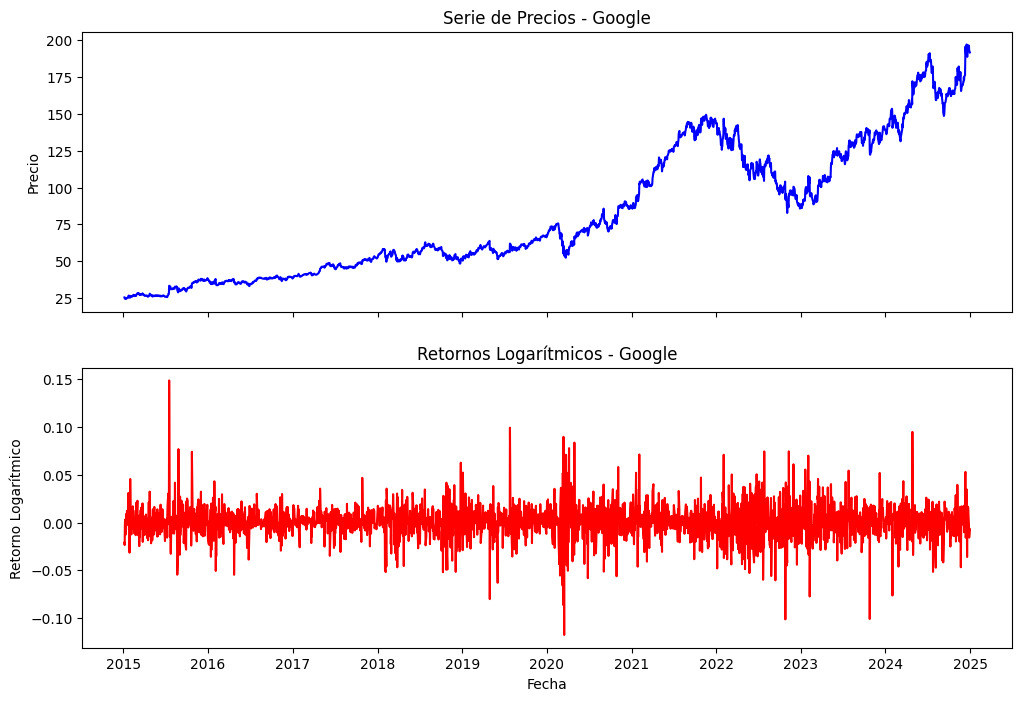

In [28]:
# Gráfico de la serie de precios y retornos logarítmicos de Google
fig, ax = plt.subplots(2, 1, figsize=(12,8), sharex=True)
ax[0].plot(data_google['Close'], color='blue')
ax[0].set_title('Serie de Precios - Google')
ax[0].set_ylabel('Precio')
ax[1].plot(data_google['Log_Return'], color='red')
ax[1].set_title('Retornos Logarítmicos - Google')
ax[1].set_ylabel('Retorno Logarítmico')
ax[1].set_xlabel('Fecha')
plt.show()


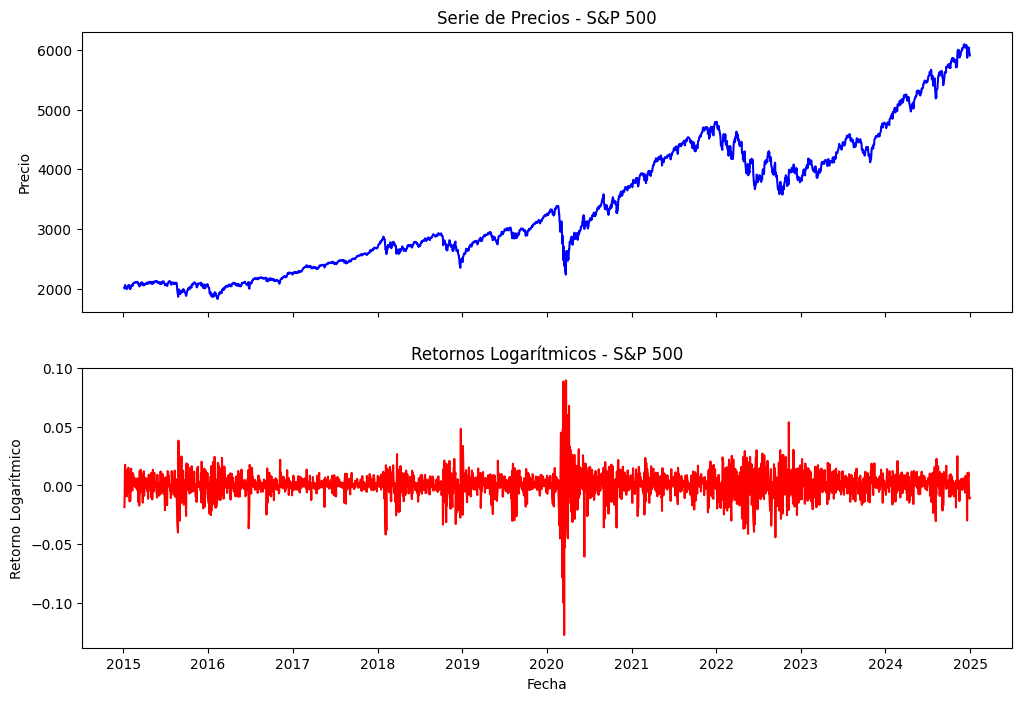

In [29]:
# Gráfico de la serie de precios y retornos logarítmicos del S&P 500
fig, ax = plt.subplots(2, 1, figsize=(12,8), sharex=True)
ax[0].plot(data_sp500['Close'], color='blue')
ax[0].set_title('Serie de Precios - S&P 500')
ax[0].set_ylabel('Precio')
ax[1].plot(data_sp500['Log_Return'], color='red')
ax[1].set_title('Retornos Logarítmicos - S&P 500')
ax[1].set_ylabel('Retorno Logarítmico')
ax[1].set_xlabel('Fecha')
plt.show()

**2.** Calcule skewness y kurtosis muestral de los retornos. Compárela con la normal (skew=0, kurt=3) y con la curtosis teórica derivada en 1.3(a) evaluada en los parámetros que estime en 4.2.

In [30]:
#Cálculo skewness y kurtosis muestral de los retornos

print("Skewness muestral de los retornos de Google:", data_google['Log_Return'].skew())
print("Kurtosis muestral de los retornos de Google:", data_google['Log_Return'].kurtosis())

print("Skewness muestral de los retornos del S&P 500:", data_sp500['Log_Return'].skew())
print("Kurtosis muestral de los retornos del S&P 500:", data_sp500['Log_Return'].kurtosis())

Skewness muestral de los retornos de Google: 0.04089993548022463
Kurtosis muestral de los retornos de Google: 6.190915298680077
Skewness muestral de los retornos del S&P 500: -0.8108304888405599
Kurtosis muestral de los retornos del S&P 500: 15.750819264863397


In [31]:

from scipy.stats import skew, kurtosis

# Cálculo de skewness y kurtosis (skew=0, kurt=3)
estadisticas = pd.DataFrame({
    'Activo': ['Google', 'S&P 500'],
    'Skewness': [
        skew(data_google['Log_Return']),
        skew(data_sp500['Log_Return'])
    ],
    'Kurtosis': [
        kurtosis(data_google['Log_Return'], fisher=False),
        kurtosis(data_sp500['Log_Return'], fisher=False)
    ]
})

print(estadisticas.round(4))

    Activo  Skewness  Kurtosis
0   Google    0.0409    9.1762
1  S&P 500   -0.8103   18.7171


 Comparación con la curtosis teórica derivada en 1.3(a) evaluada en los parámetros que estime en 4.2.

Grafique el histograma de retornos junto a una densidad normal y una 
t-Student ajustadas. ¿Cuál se ajusta mejor a las colas?

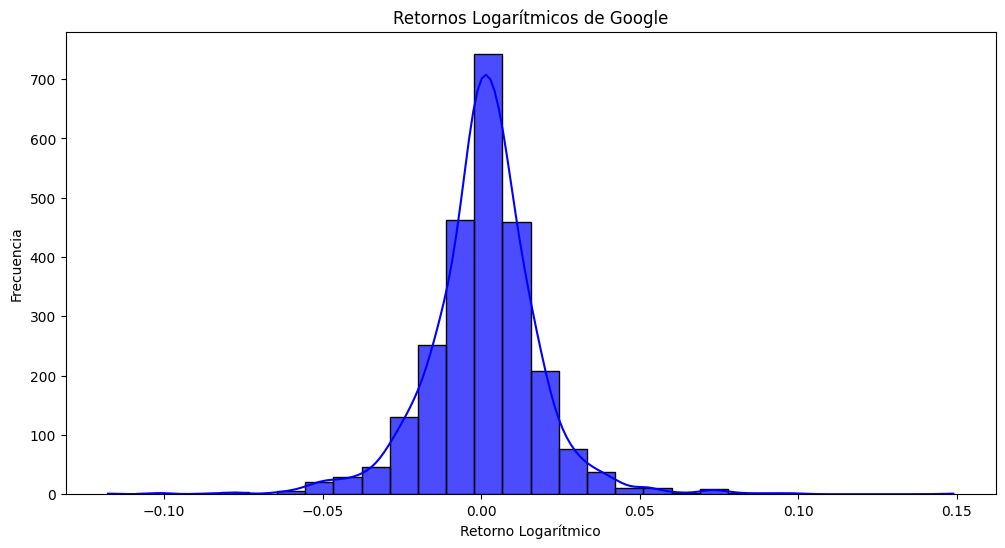

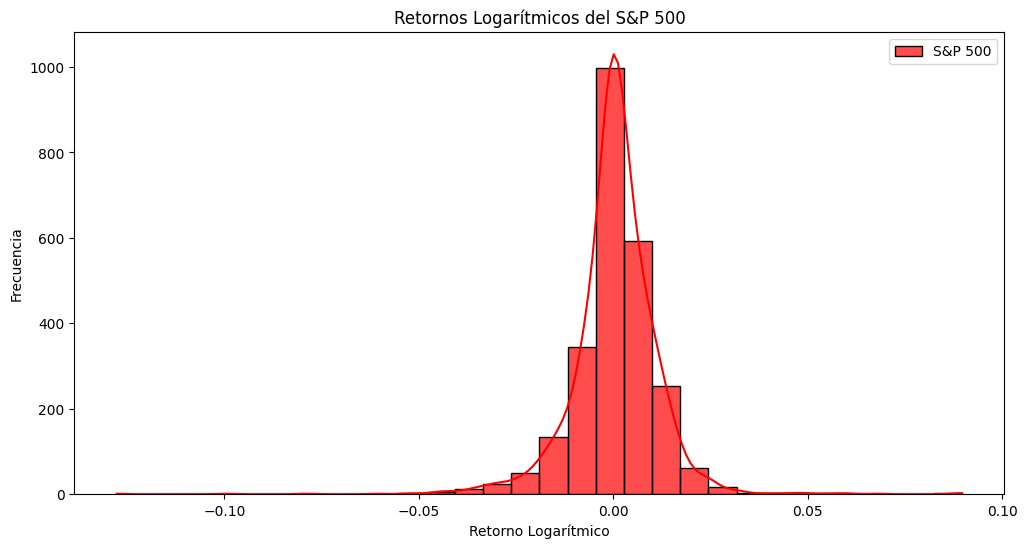

In [32]:
import seaborn as sns

# Gráfico histograma de los retornos logarítmicos de Google y S&P 500

plt.figure(figsize=(12,6))
sns.histplot(data=data_google, x='Log_Return', bins=30, alpha=0.7, color='blue', label='Google', kde=True)
plt.xlabel('Retorno Logarítmico')
plt.ylabel('Frecuencia')
plt.title('Retornos Logarítmicos de Google')

plt.figure(figsize=(12,6))
sns.histplot(data=data_sp500, x='Log_Return', bins=30, alpha=0.7, color='red', label='S&P 500', kde=True)
plt.xlabel('Retorno Logarítmico')
plt.ylabel('Frecuencia')
plt.title('Retornos Logarítmicos del S&P 500')

plt.legend()
plt.show()

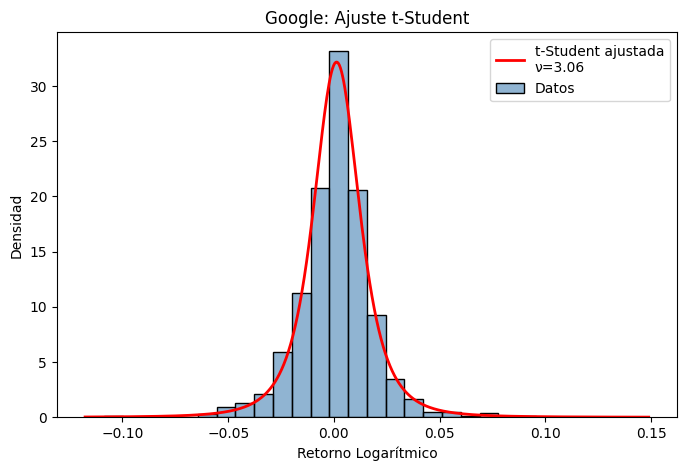

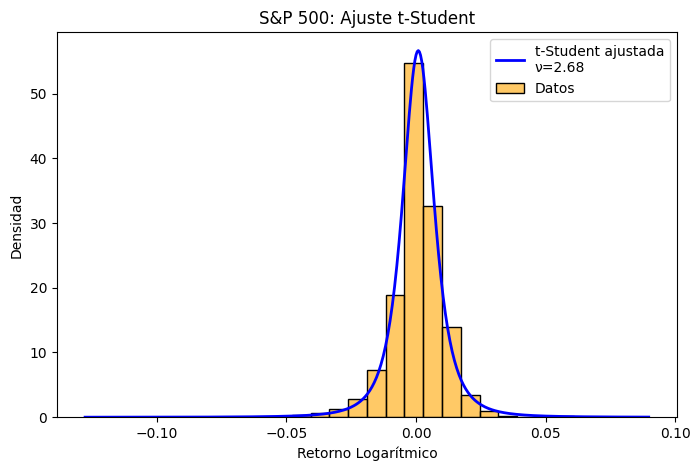

In [33]:
# Gráfico t-student de los retornos logarítmicos de Google y S&P 500

from scipy.stats import t

# Google
ret_google = data_google['Log_Return'].dropna()

# Ajustar distribución t-Student
df_g, loc_g, scale_g = t.fit(ret_google)

# Rango para la curva
x = np.linspace(ret_google.min(), ret_google.max(), 500)

plt.figure(figsize=(8,5))

# Histograma
sns.histplot(ret_google, bins=30, stat='density',
             color='steelblue', alpha=0.6, label='Datos')

# Curva t-Student ajustada
plt.plot(x, t.pdf(x, df_g, loc_g, scale_g),
         color='red', lw=2,
         label=f't-Student ajustada\nν={df_g:.2f}')

plt.title('Google: Ajuste t-Student')
plt.xlabel('Retorno Logarítmico')
plt.ylabel('Densidad')
plt.legend()
plt.show()


# S&P 500
ret_sp500 = data_sp500['Log_Return'].dropna()

# Ajustar distribución t-Student
df_s, loc_s, scale_s = t.fit(ret_sp500)

# Rango para la curva
x = np.linspace(ret_sp500.min(), ret_sp500.max(), 500)

plt.figure(figsize=(8,5))

# Histograma
sns.histplot(ret_sp500, bins=30, stat='density',
             color='orange', alpha=0.6, label='Datos')

# Curva t-Student ajustada
plt.plot(x, t.pdf(x, df_s, loc_s, scale_s),
         color='blue', lw=2,
         label=f't-Student ajustada\nν={df_s:.2f}')

plt.title('S&P 500: Ajuste t-Student')
plt.xlabel('Retorno Logarítmico')
plt.ylabel('Densidad')
plt.legend()
plt.show()
 

la distribución t-Student suele ajustarse mejor a las colas que la distribución normal.

La razón es que los retornos financieros presentan con frecuencia colas pesadas (fat tails), es decir, ocurren movimientos extremos con una probabilidad mayor que la predicha por una distribución normal. La distribución t-Student incorpora esta característica mediante el parámetro de grados de libertad ν:

ν pequeño: colas muy pesadas y mayor probabilidad de valores extremos.
ν grande: la distribución se aproxima a una normal.

En este caso el S&P 500 tiene un ν menor, por lo que tiene colas más pesadas que Google.

**4.** Grafique la volatilidad móvil (ventana de 20 días) para evidenciar clustering.

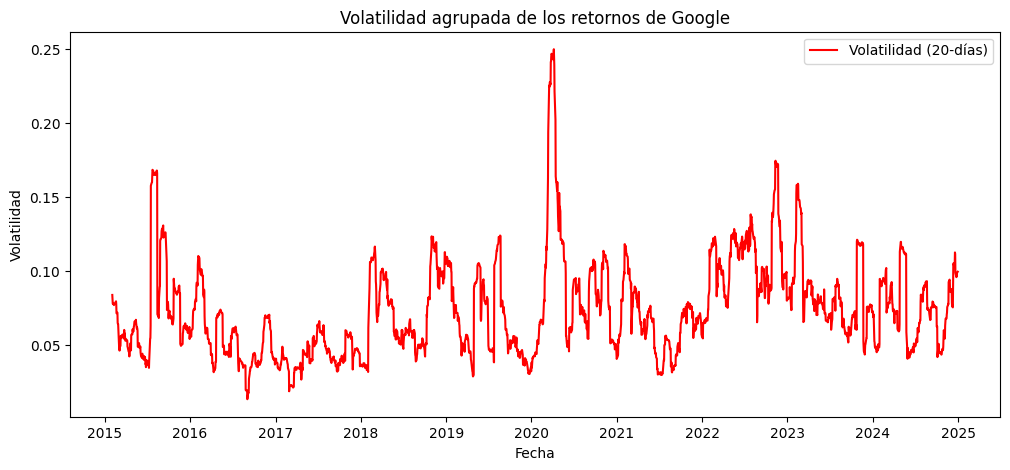

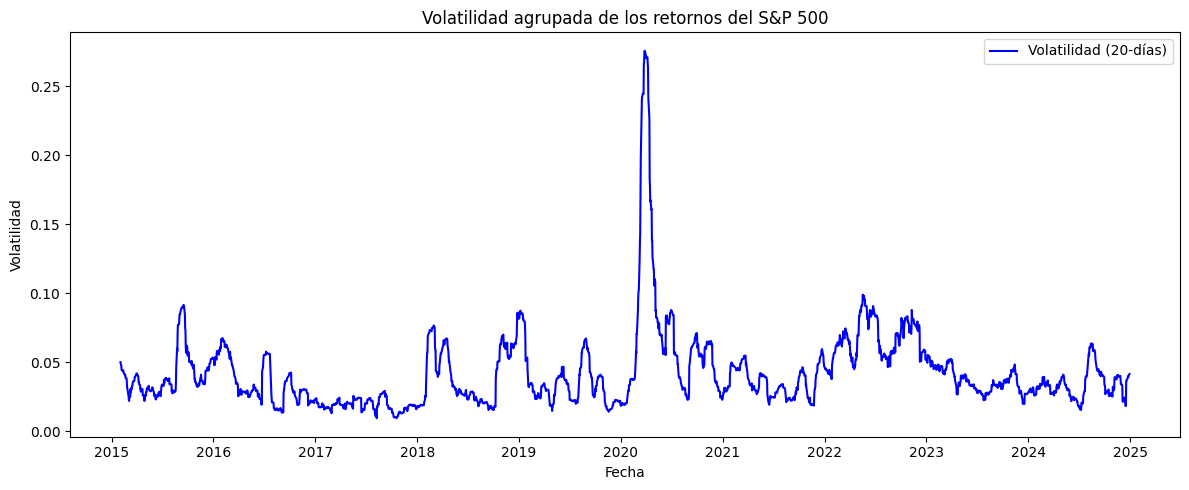

In [39]:
#Gráfico de volatilidad móvil y retornos logarítmicos de Google y S&P 500

from matplotlib.pyplot import plot

#Roolling Volatilidad Google 20 días
data_google['Volatility'] = data_google['Log_Return'].rolling(window = 20).std() * np.sqrt(20)

#Roolling Volatilidad S&P 500 20 días
data_sp500['Volatility'] = data_sp500['Log_Return'].rolling(window = 20).std() * np.sqrt(20)

# Volatilidad agrupada de los retornos de Google
plt.figure(figsize=(12,5))
plot(data_google['Volatility'], color='red', label=f'Volatilidad ({20}-días)')
plt.title('Volatilidad agrupada de los retornos de Google')
plt.xlabel('Fecha')
plt.ylabel('Volatilidad')
plt.legend()

# Volatilidad agrupada de los retornos de S&P 500
plt.figure(figsize=(12,5))
plot(data_sp500['Volatility'], color='blue', label=f'Volatilidad ({20}-días)')
plt.title('Volatilidad agrupada de los retornos del S&P 500')
plt.xlabel('Fecha')
plt.ylabel('Volatilidad')
plt.legend()

plt.tight_layout()
plt.show()

Calcule la compensación entre $r_{t-1}$ y $r_t^2$ (proxy simple del efecto apalancamiento). ¿El signo es consistente con lo esperado?

In [ ]:
# Construcción de las variables
df1 = data_google[['Log_Return']].copy()

df1['r_t-1'] = df1['Log_Return'].shift(1)
df1['r_t^2'] = df1['Log_Return']**2

df1 = df1.dropna()

# Correlación
corr = df1['r_t-1'].corr(df1['r_t^2'])

print(f"Correlación entre r_(t-1) y r_t^2: {corr:.4f}")

Correlación entre r_(t-1) y r_t^2: -0.0012


Correlación negativa: consistente con el efecto apalancamiento. Un retorno negativo en t−1 tiende a estar asociado con una mayor volatilidad en t.
Correlación cercana a cero: poca evidencia de efecto apalancamiento mediante esta medida simple.
Correlación positiva: no es consistente con el efecto apalancamiento y sugiere que los retornos negativos no incrementan la volatilidad más que los positivos.

## 4.2 Selección del Modelo: Grilla de Especificaciones

Para cada activo, ajuste **los cuatro modelos** vistos en clases (`ARCH`, `GARCH`, `EGARCH`, `GJR-GARCH`, todos con $p=q=1$, y $o=1$ donde corresponde) cruzados con **tres distribuciones** (`normal`, `t`, `skewt`) — 12 modelos por activo.

In [45]:
# Modelos ARCH, GRACH, EGARCH y GJR-GARCH para los retornos de Google

# Genero Retornos de Google (escalar por 100)
returns_google = 100*data_google['Close'].pct_change().dropna()

# Estimación de un modelo ARCH de Google
model_g  = arch_model(returns_google, vol='ARCH', p = 1)
result_arch_g = model_g.fit()

# Resumen del modelo ajustado
print(result_arch_g.summary())



Iteration:      1,   Func. Count:      5,   Neg. LLF: 11393.702183238896
Iteration:      2,   Func. Count:     12,   Neg. LLF: 7098.255775445712
Iteration:      3,   Func. Count:     19,   Neg. LLF: 5035.006906393756
Iteration:      4,   Func. Count:     25,   Neg. LLF: 4945.382670701412
Iteration:      5,   Func. Count:     29,   Neg. LLF: 4945.38266579135
Iteration:      6,   Func. Count:     32,   Neg. LLF: 4945.3826657913505
Optimization terminated successfully    (Exit mode 0)
            Current function value: 4945.38266579135
            Iterations: 6
            Function evaluations: 32
            Gradient evaluations: 6
                      Constant Mean - ARCH Model Results                      
Dep. Variable:                  Close   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                       ARCH   Log-Likelihood:               -4945.38
Distribution:                  Normal   AIC: 

In [ ]:
# Estimación de un modelo GARCH(1, 1) de Google
model_garch = arch_model(returns_google, vol='GARCH', p=1, q=1)
results_garch = model_garch.fit(disp='off')
print(results_garch.summary())


                     Constant Mean - GARCH Model Results                      
Dep. Variable:                  Close   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -4875.37
Distribution:                  Normal   AIC:                           9758.74
Method:            Maximum Likelihood   BIC:                           9782.06
                                        No. Observations:                 2513
Date:                Thu, Jul 09 2026   Df Residuals:                     2512
Time:                        00:39:37   Df Model:                            1
                                Mean Model                                
                 coef    std err          t      P>|t|    95.0% Conf. Int.
--------------------------------------------------------------------------
mu             0.1038  3.475e-02      2.987  2.814e-03 [3.570e-0

In [46]:
# Estimación de un modelo EGARCH(1, 1) de Google
model_egarch_g = arch_model(returns_google, vol='EGARCH', p=1, q=1)
results_egarch_g = model_egarch_g.fit(disp='off')
print(results_egarch_g.summary())

                     Constant Mean - EGARCH Model Results                     
Dep. Variable:                  Close   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                     EGARCH   Log-Likelihood:               -4849.59
Distribution:                  Normal   AIC:                           9707.17
Method:            Maximum Likelihood   BIC:                           9730.49
                                        No. Observations:                 2513
Date:                Thu, Jul 09 2026   Df Residuals:                     2512
Time:                        00:42:25   Df Model:                            1
                                Mean Model                                
                 coef    std err          t      P>|t|    95.0% Conf. Int.
--------------------------------------------------------------------------
mu             0.0855  3.502e-02      2.442  1.460e-02 [1.689e-0

In [47]:
# Estimación de un modelo GJR-GARCH(1, 1) de Google
model_gjr_garch_g = arch_model(returns_google, vol='GARCH', p=1, q=1, o=1, dist='normal')
results_gjr_garch_g = model_gjr_garch_g.fit(disp='off')
print(results_gjr_garch_g.summary())

                   Constant Mean - GJR-GARCH Model Results                    
Dep. Variable:                  Close   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                  GJR-GARCH   Log-Likelihood:               -4873.68
Distribution:                  Normal   AIC:                           9757.35
Method:            Maximum Likelihood   BIC:                           9786.50
                                        No. Observations:                 2513
Date:                Thu, Jul 09 2026   Df Residuals:                     2512
Time:                        00:43:18   Df Model:                            1
                                Mean Model                                
                 coef    std err          t      P>|t|    95.0% Conf. Int.
--------------------------------------------------------------------------
mu             0.0940  3.305e-02      2.844  4.457e-03 [2.921e-0